## Gerar o embedding de frases.
## Gerar as funções que extraem metricas:
- distancia euclidiana
- similaridade do cosseno
- distancia do cosseno
## Comparar as metricas de comparação dentre duas frases
## Conclusões

In [ ]:
from google.colab import userdata
OPENROUTER_API_KEY=userdata.get('OPENROUTER_API_KEY')
import os
os.environ["OPENROUTER_API_KEY"] = OPENROUTER_API_KEY

In [ ]:
import requests

# Replace <YOUR_OPENROUTER_API_KEY> with your actual API key
# It's recommended to store API keys securely, e.g., using environment variables or Colab's Secrets feature.
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY") # TODO: Replace with your actual key

response = requests.post(
  "https://openrouter.ai/api/v1/embeddings",
  headers={
    "Authorization": f"Bearer {OPENROUTER_API_KEY}",
    "Content-Type": "application/json",
  },
  json={
    "model": "openai/text-embedding-3-small",
    "input": "The quick brown fox jumps over the lazy dog"
  }
)

data = response.json()

# Check if the API call was successful before attempting to access 'data'
if response.status_code == 200 and "data" in data:
    embedding = data["data"][0]["embedding"]
    print(f"Embedding dimension: {len(embedding)}")
else:
    print(f"API request failed with status code {response.status_code}")
    print(f"Error response: {data}")
    print("Please ensure your OPENROUTER_API_KEY is correct and has the necessary permissions.")

Embedding dimension: 1536


In [ ]:
import requests
import os

def get_embeddings(texto):
  # Obtém a chave da API OpenRouter das variáveis de ambiente
  OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")

  # Verifica se a chave da API está configurada
  if not OPENROUTER_API_KEY:
    print("Erro: OPENROUTER_API_KEY não está configurada. Certifique-se de que ela seja carregada dos segredos do Colab ou variáveis de ambiente.")
    return None

  # Faz a requisição POST para a API de embeddings da OpenRouter
  response = requests.post(
    "https://openrouter.ai/api/v1/embeddings",
    headers={
      "Authorization": f"Bearer {OPENROUTER_API_KEY}",
      "Content-Type": "application/json",
    },
    json={
      "model": "openai/text-embedding-3-small",
      "input": texto
    }
  )

  # Converte a resposta para JSON
  data = response.json()

  # Verifica se a chamada da API foi bem-sucedida antes de tentar acessar 'data'
  if response.status_code == 200 and "data" in data:
      # Retorna o embedding gerado
      return data["data"][0]["embedding"]
  else:
      # Imprime a mensagem de erro se a chamada da API falhar
      print(f"A requisição da API falhou com o código de status {response.status_code}")
      print(f"Resposta de erro: {data}")
      print("Por favor, verifique se sua OPENROUTER_API_KEY está correta e tem as permissões necessárias.")
      return None

In [ ]:
texto = 'O carro é veloz.'

In [ ]:
get_embeddings(texto)

[-0.003803253173828125,
 0.020111083984375,
 -0.10540771484375,
 -0.005886077880859375,
 -0.004573822021484375,
 0.0233154296875,
 -0.044708251953125,
 0.0411376953125,
 0.01544189453125,
 -0.0224609375,
 -0.01244354248046875,
 0.01528167724609375,
 -0.06695556640625,
 -0.020294189453125,
 0.047637939453125,
 -0.01465606689453125,
 -0.0195770263671875,
 -0.033477783203125,
 0.023406982421875,
 -0.04522705078125,
 0.0014352798461914062,
 -0.018096923828125,
 0.0176849365234375,
 -0.00897216796875,
 -0.0166778564453125,
 -0.0243682861328125,
 0.0182342529296875,
 -0.0345458984375,
 -0.02142333984375,
 -0.0251007080078125,
 0.056427001953125,
 -0.038055419921875,
 0.042877197265625,
 -0.048370361328125,
 -0.020050048828125,
 0.02423095703125,
 -0.0140228271484375,
 -0.019378662109375,
 -0.0228424072265625,
 0.00344085693359375,
 0.020111083984375,
 0.0408935546875,
 -0.0019140243530273438,
 0.0286712646484375,
 0.073974609375,
 -0.0095367431640625,
 0.0034027099609375,
 -0.011642456054687

## Tokens gastos

In [ ]:
if 'usage' in data:
    prompt_tokens = data['usage'].get('prompt_tokens')
    total_tokens = data['usage'].get('total_tokens')
    cost = data['usage'].get('cost')
    print(f"Prompt Tokens: {prompt_tokens}")
    print(f"Total Tokens: {total_tokens}")
    print(f"Cost: {cost}")
else:
    print("Informações de uso de tokens não encontradas na resposta da API.")

Prompt Tokens: 9
Total Tokens: 9
Cost: 1.8e-07


## Checar a similaridade de termos

## Termos
- gato, felino, cachorro, carro, caminhao, moto, banana, maça, goiaba

In [ ]:
import re
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Extrair os embeddings
termos = "gato, felino, cachorro, carro, caminhao, moto, banana, maça, goiaba"
termos = [termo.strip() for termo in termos.split(',')]

print("Termos extraídos:", termos)

Termos extraídos: ['gato', 'felino', 'cachorro', 'carro', 'caminhao', 'moto', 'banana', 'maça', 'goiaba']


In [ ]:
# Generate embeddings for each term
embeddings = {}
for term in termos:
    print(f"Gerando embedding para: {term}")
    embedding = get_embeddings(term)
    if embedding is not None:
        embeddings[term] = embedding
    else:
        print(f"Não foi possível obter embedding para {term}")

if not embeddings:
    print("Nenhum embedding foi gerado. Verifique a função get_embeddings e a chave da API.")

Gerando embedding para: gato
Gerando embedding para: felino
Gerando embedding para: cachorro
Gerando embedding para: carro
Gerando embedding para: caminhao
Gerando embedding para: moto
Gerando embedding para: banana
Gerando embedding para: maça
Gerando embedding para: goiaba


In [ ]:
# Calculate cosine similarity between all pairs of embeddings
similarity_matrix = pd.DataFrame(index=embeddings.keys(), columns=embeddings.keys())

for term1, emb1 in embeddings.items():
    for term2, emb2 in embeddings.items():
        # Reshape for cosine_similarity function (expects 2D arrays)
        sim = cosine_similarity([emb1], [emb2])[0][0]
        similarity_matrix.loc[term1, term2] = sim

# Display the similarity matrix
display(similarity_matrix)

,gato,felino,cachorro,carro,caminhao,moto,banana,maça,goiaba
gato,1.0,0.636356,0.521117,0.380597,0.260447,0.344959,0.229322,0.367712,0.303022
felino,0.636356,1.0,0.443531,0.283648,0.252156,0.308468,0.171896,0.295826,0.199659
cachorro,0.521117,0.443531,1.0,0.400327,0.382419,0.285448,0.203014,0.394436,0.291139
carro,0.380597,0.283648,0.400327,1.0,0.452227,0.434041,0.236698,0.303231,0.268466
caminhao,0.260447,0.252156,0.382419,0.452227,1.0,0.467636,0.187734,0.377306,0.334571
moto,0.344959,0.308468,0.285448,0.434041,0.467636,1.0,0.215723,0.34796,0.248182
banana,0.229322,0.171896,0.203014,0.236698,0.187734,0.215723,1.0,0.398484,0.322519
maça,0.367712,0.295826,0.394436,0.303231,0.377306,0.34796,0.398484,1.0,0.445255
goiaba,0.303022,0.199659,0.291139,0.268466,0.334571,0.248182,0.322519,0.445255,1.0


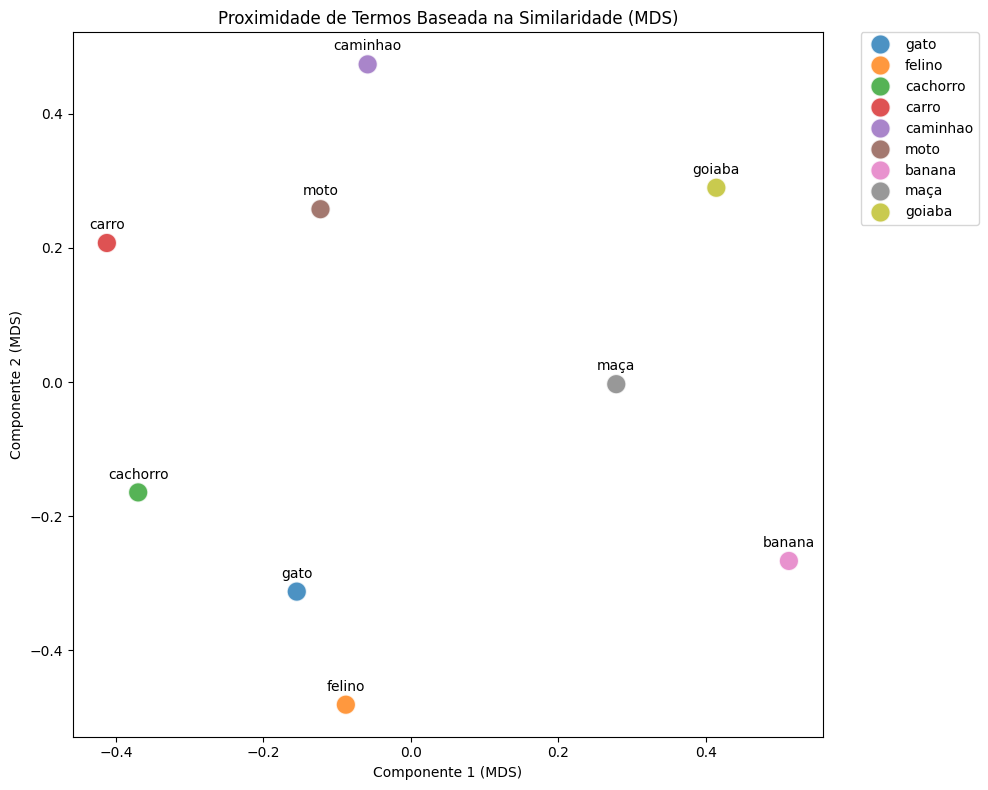

In [ ]:
from sklearn.manifold import MDS
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# A MDS trabalha com matriz de dissimilaridade, então convertemos a similaridade
dissimilarity_matrix = 1 - similarity_matrix

# Crie uma instância do MDS e ajuste-a aos dados
# n_components=2 para reduzir a 2 dimensões para visualização
# dissimilarity='precomputed' porque já fornecemos a matriz de dissimilaridade
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress=False)
mds_coords = mds.fit_transform(dissimilarity_matrix)

# Crie um DataFrame para as coordenadas e os termos
mds_df = pd.DataFrame(mds_coords, columns=['Componente 1', 'Componente 2'], index=similarity_matrix.index)

plt.figure(figsize=(10,8)) # Aumentei o tamanho da figura para acomodar a legenda
sns.scatterplot(x='Componente 1', y='Componente 2', data=mds_df, s=200, alpha=0.8, hue=mds_df.index, palette='tab10', legend='full') # Adiciona cores para cada termo e habilita a legenda completa

# Adicione rótulos para cada ponto
for i, term in enumerate(mds_df.index):
    plt.annotate(term, (mds_df.iloc[i, 0], mds_df.iloc[i, 1]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Proximidade de Termos Baseada na Similaridade (MDS)')
plt.xlabel('Componente 1 (MDS)')
plt.ylabel('Componente 2 (MDS)')
plt.grid(False) # Removendo a grade
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) # Posiciona a legenda fora do gráfico
plt.tight_layout()
plt.show()

## 1 - Distancia Euclidiana

Crie uma função chamada `distancia_euclidiana()` que receba dois embeddings e retorne a **distância euclidiana** entre eles.

A distância euclidiana é calculada considerando a diferença entre cada uma das dimensões dos dois vetores.

Sua função deve ser capaz de receber dois vetores de qualquer dimensão, desde que possuam o mesmo tamanho.

Exemplo de uso:

- distancia = distancia_euclidiana(embedding_a, embedding_b)
print(distancia)

## 2 - Distancia de Cosseno

Agora crie uma função chamada `distancia_cosseno()` que receba os mesmos dois embeddings e retorne a **distância de cosseno** entre eles.

Para isso, utilize o conceito de similaridade de cosseno entre dois vetores.

Exemplo de uso:

- distancia = distancia_cosseno(embedding_a, embedding_b)
print(distancia)

## 3 - Testando as funções

Crie alguns embeddings de teste e utilize as duas funções para comparar diferentes pares de vetores.

Calcule:

- A distância entre `embedding_a` e `embedding_b`;
- A distância entre `embedding_a` e `embedding_c`;
- A distância entre `embedding_b` e `embedding_c`.

Termos para usar no embeddings:

gato, felino, cachorro, carro, caminhão, moto, banana, maça, goiaba

In [ ]:
import math

def distancia_euclidiana(embedding1, embedding2):
    if len(embedding1) != len(embedding2):
        raise ValueError("Os embeddings devem ter o mesmo tamanho.")

    soma = sum((a - b) ** 2 for a, b in zip(embedding1, embedding2))
    return math.sqrt(soma)


In [ ]:
import math

def similaridade_cosseno(embedding1, embedding2):
    if len(embedding1) != len(embedding2):
        raise ValueError("Os embeddings devem ter o mesmo tamanho.")

    # Produto escalar
    produto = sum(a * b for a, b in zip(embedding1, embedding2))

    # Normas
    norma1 = math.sqrt(sum(a ** 2 for a in embedding1))
    norma2 = math.sqrt(sum(b ** 2 for b in embedding2))

    return produto / (norma1 * norma2)


In [ ]:
import math

def distancia_cosseno(embedding1, embedding2):
    if len(embedding1) != len(embedding2):
        raise ValueError("Os embeddings devem ter o mesmo tamanho.")

    # Produto escalar
    produto = sum(a * b for a, b in zip(embedding1, embedding2))

    # Norma dos vetores
    norma1 = math.sqrt(sum(a**2 for a in embedding1))
    norma2 = math.sqrt(sum(b**2 for b in embedding2))

    similaridade = produto / (norma1 * norma2)

    return 1 - similaridade

In [ ]:
import numpy as np
import pandas as pd

frase_ancora = "O cachorro correu no parque e brincou com a bola."

frases_comparacao = [
    ("Identicas)", "O cachorro correu no parque e brincou com a bola."),
    ("Similar (mesmo sentido, palavras diferentes)", "Um cão estava correndo no jardim e brincando com seu brinquedo."),
    ("Relacionado (mesmo contexto de animais)", "O gato dormiu na almofada da sala durante toda a tarde."),
    ("Diferente (outro domínio - economia)", "A taxa de juros do banco central subiu dois pontos percentuais."),
    ("Oposto/Negação", "Nenhum animal esteve no parque e o cão permaneceu preso em casa."),
    ("frase_ancora negada","O cachorro não correu no parque e não brincou com a bola.")
]

# 1. Gerar o embedding da âncora e converter para np.array
vec_ancora = np.array(get_embeddings(frase_ancora), dtype=np.float32)

# 2. Gerar os embeddings das comparações e garantir que sejam np.array
vecs_comp = []
for _, frase_texto in frases_comparacao:
    # Extrair apenas o texto da frase para gerar o embedding
    vec = get_embeddings(frase_texto)
    if vec is not None:
        vecs_comp.append(np.array(vec, dtype=np.float32))
    else:
        vecs_comp.append(None) # Adiciona None se o embedding falhar

# 3. Montar os resultados (ajustado para 'texto' simples no loop)
resultados = []
for i, (label, texto) in enumerate(frases_comparacao):
    vec = vecs_comp[i]
    if vec is not None:
        resultados.append({
            "Categoria": label, # Alterado 'Texto' para 'Categoria' para melhor clareza
            "Frase": texto,
            "Dist. Euclidiana": round(distancia_euclidiana(vec_ancora, vec), 4),
            "Similaridade Cosseno": round(similaridade_cosseno(vec_ancora, vec), 4),
            "Distância Cosseno": round(distancia_cosseno(vec_ancora, vec), 4)
        })
    else:
        resultados.append({
            "Categoria": label,
            "Frase": texto,
            "Dist. Euclidiana": "N/A",
            "Similaridade Cosseno": "N/A",
            "Distância Cosseno": "N/A"
        })

df_resultados = pd.DataFrame(resultados)
display(df_resultados)

,Categoria,Frase,Dist. Euclidiana,Similaridade Cosseno,Distância Cosseno
0,Identicas),O cachorro correu no parque e brincou com a bola.,0.0000,1.0000,0.0000
1,"Similar (mesmo sentido, palavras diferentes)",Um cão estava correndo no jardim e brincando c...,0.6838,0.7662,0.2338
2,Relacionado (mesmo contexto de animais),O gato dormiu na almofada da sala durante toda...,1.1139,0.3796,0.6204
3,Diferente (outro domínio - economia),A taxa de juros do banco central subiu dois po...,1.2395,0.2317,0.7683
4,Oposto/Negação,Nenhum animal esteve no parque e o cão permane...,0.9266,0.5707,0.4293
5,frase_ancora negada,O cachorro não correu no parque e não brincou ...,0.5407,0.8539,0.1461


## Observações:

## - frases identicas
- distancia euclidiana: valor de 0.0009, nao existe separação.
- similaridade do cosseno: 100%
- distancia do cosseno: 0.000, não existe separação entre as frases, apontam na mesma direção e tem angulo zero.

## - frases similares
- distancia euclidiana: valor de 0.68,  termos similares, mas apresentam uma distancia entre os termos.
- similaridade do cosseno: 77%
- distancia do cosseno: 0.23, apresentam certa distancia, apontam mesmo lado, mas tem angulo.

## - relacionado (contexto de animais)
- distancia euclidiana: valor de 1.11, contexto iguais, ambas tem animais, mas a maioria dos termos sao outros
- similaridade do cosseno: 37%, animais diferentes, locais diferentes
- distancia do cosseno: 0.62, tem certa distancia e angulo entre elas

## - diferente (dominios #)
- distancia euclidiana: valor de 1.23, termos dfierentes.
- similaridade do cosseno: 23%
- distancia do cosseno: 0.77, apontam para lados diferentes, geram um angulo alto.

## - Oposto (negação)
- distancia euclidiana: valor de 0.92
- similaridade do cosseno: 57%, termos iguais, mas o contexto é negado, por isso não é alta a similaridade.
- distancia do cosseno: 0.42, o contexto negado, afasta e gera um angulo.

## - frase ancora negada
- a distancia euclidiana: valor de 0.54 foi impactada, pela inclusão dos termos não.
- similaridade do cosseno: 87%%, pouco impactada, porque os termos principais estão presentes, por isso manteve uma alta similaridade.
- distancia do cosseno: 0.14, pouco impactada, pois os termos principais se mantem.
